## Miscellaneous Cleaning

In this notebook, we will clean up the data by:

1. Reducing target categories to only 2 main classes: `Fully Paid` and `Charged Off`
2. Remove features with greater than <ins>60%</ins> null values 
3. Remove features that would cause significant and immediate data leakage 
4. Remove target variables that are null 
5. Split the data into <ins>training</ins> and <ins>test set</ins>


In [57]:
# first we load the data 

import pandas as pd 

filepath = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/raw/accepted_2007_to_2018Q4.csv"

df = pd.read_csv(filepath)

/var/folders/19/sr0vg3y90ns0sp5j74zth4h80000gn/T/ipykernel_59590/3968319031.py:7: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


#### Reducing Unique Loan Statuses

In [58]:
class_dist = df.groupby('loan_status')['loan_status'].count().to_frame()

class_dist

,loan_status
loan_status,
Charged Off,268559
Current,878317
Default,40
Does not meet the credit policy. Status:Charged Off,761
Does not meet the credit policy. Status:Fully Paid,1988
Fully Paid,1076751
In Grace Period,8436
Late (16-30 days),4349
Late (31-120 days),21467


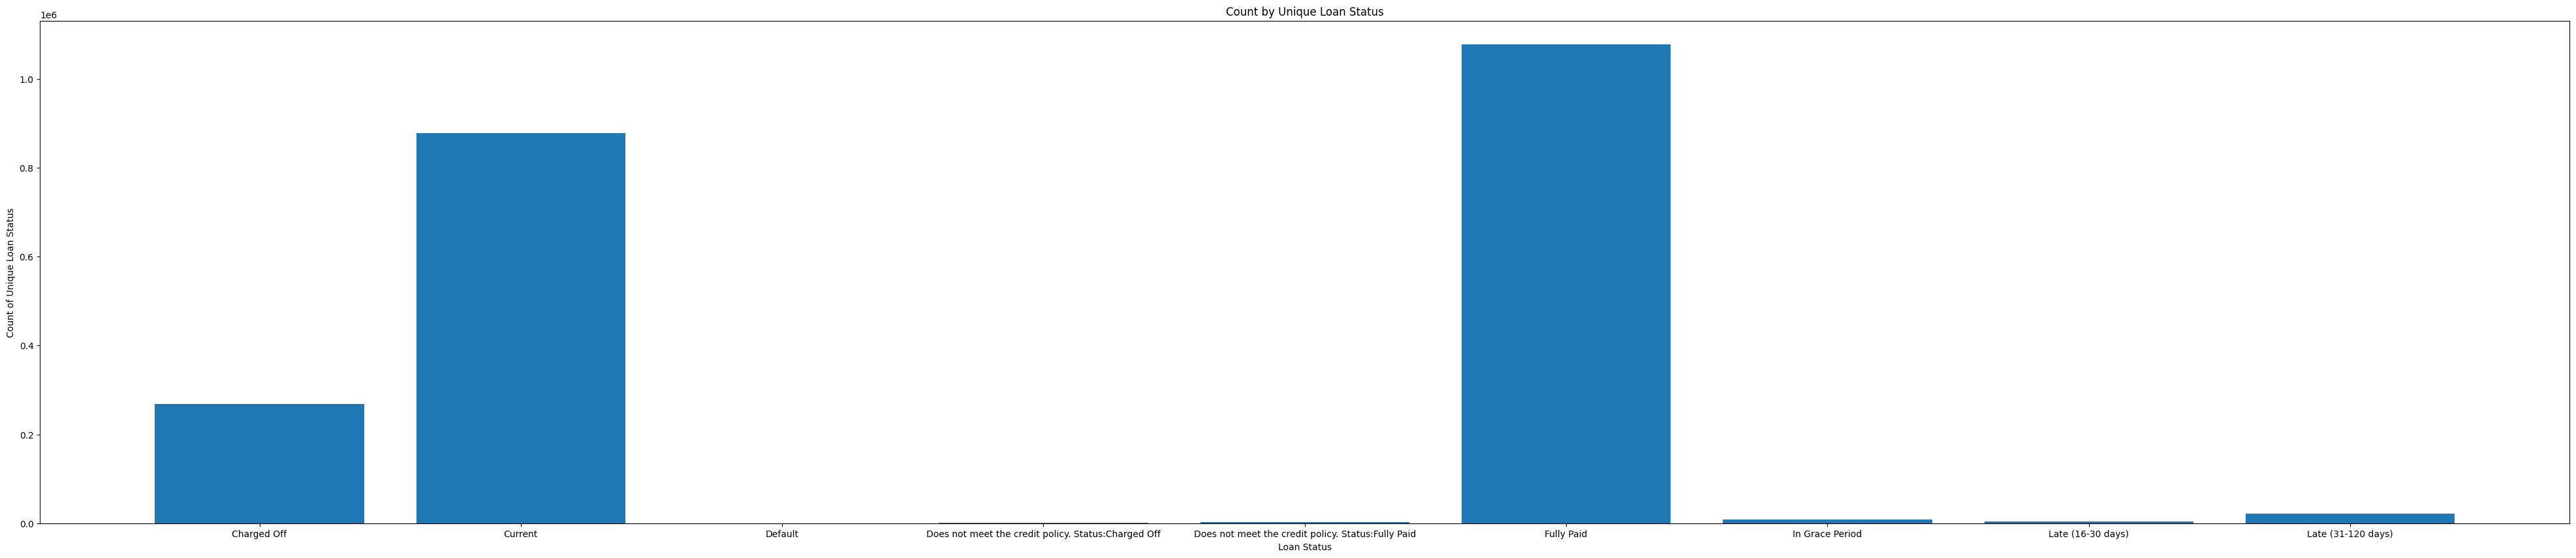

In [59]:
# plot a bar chart of the class distributions 

import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(50, 10))

loan_statuses = class_dist.index
count = class_dist['loan_status'].to_list()

ax.bar(loan_statuses, count)

ax.set_ylabel('Count of Unique Loan Status')
ax.set_xlabel('Loan Status')
ax.set_title('Count by Unique Loan Status')

plt.show()

- We will drop rows with loan status as`Current` and `In Grace Period` because we are only interested loans that have been `Charged Off` or `Fully Paid`.
- We will also do the same thing with `Does not meet the credit policy. Status:Fully Paid` and `Does not meet the credit policy. Status:Charged Off` as they are irrelevant.
- We group `Default` loans as `Charged Off. 
- We group `Late (16-30 days)` and `Late (31-120 days)` in the same category as `Charged Off` as we group serious late and delinquint loans with the same as that being charged off.

In [60]:
# grouping and dropping logic 

df.drop(df.loc[(df['loan_status'] == 'Current') | (df['loan_status'] == 'In Grace Period') | (df['loan_status'] == 'Does not meet the credit policy. Status:Fully Paid') | (df['loan_status'] == 'Does not meet the credit policy. Status:Charged Off')].index, inplace=True)

df.loc[df['loan_status'] == 'Late (16-30 days)', 'loan_status'] = 'Charged Off'

df.loc[df['loan_status'] == 'Late (31-120 days)', 'loan_status'] = 'Charged Off'

df.loc[df['loan_status'] == 'Default', 'loan_status'] = 'Charged Off'

#### Removing Null Target Values

In [61]:
# dropping targets with null values

df = df.dropna(subset=['loan_status'])

In [62]:
# check that there are no null target values 

df['loan_status'].isnull().sum()

np.int64(0)

#### Removing Features With High Null Values (> 60%)

In [63]:
# finding percentage of null values (as done in EDA notebook)

pd.set_option("display.max_rows", 151)
df.isnull().sum() 

id                                                  0
member_id                                     1371166
loan_amnt                                           0
funded_amnt                                         0
funded_amnt_inv                                     0
term                                                0
int_rate                                            0
installment                                         0
grade                                               0
sub_grade                                           0
emp_title                                       88314
emp_length                                      80816
home_ownership                                      0
annual_inc                                          0
verification_status                                 0
issue_d                                             0
loan_status                                         0
pymnt_plan                                          0
url                         

In [64]:
# dropping those null value

columns_to_drop = []
total_length = len(df)
for column in df.columns: 
    if df[column].isnull().sum()/total_length >= 0.60: 
        columns_to_drop.append(column)
print(columns_to_drop)

df = df.drop(columns_to_drop, axis=1, errors='ignore')

['member_id', 'desc', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'mths_since_rcnt_il', 'il_util', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date

In [65]:
df.head(3)

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N


#### Remove Data Leakage and Irrelevant Features

In [66]:
# irrelevant features 

irrelevant_feats = [
    'title', 
    'emp_title', 
    'addr_state',
    'id',
    'issue_d', 
    'url', 
    'purpose', 
    'zip_code', 
    'grade', 
    'verification_status', 
    'initial_list_status'
]

len(irrelevant_feats)

df = df.drop(irrelevant_feats, axis=1, errors='ignore')

In [67]:
# data leakage features 

leakage_feats = [
    'collection_recovery_fee', 
    'last_credit_pull_d', 
    'last_fico_range_high', 
    'last_fico_range_low', 
    'last_pymnt_amnt', 
    'last_pymnt_d', 
    'out_prncp', 
    'out_prncp_inv', 
    'recoveries', 
    'total_pymnt', 
    'total_pymnt_inv',
    'total_rec_int', 
    'total_rec_late_fee', 
    'total_rec_prncp', 
    'hardship_flag', 
    'earliest_cr_line'
]

len(leakage_feats)

df = df.drop(leakage_feats, axis=1, errors='ignore')

In [68]:
df.head(3)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C4,10+ years,MORTGAGE,55000.0,...,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,N
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C1,10+ years,MORTGAGE,65000.0,...,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,N
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B4,10+ years,MORTGAGE,63000.0,...,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,N


#### Splitting To Train And Test Sets

Given the heavy class imbalance, we will split the data into train and test sets using stratified sampling on `loan_status`

In [69]:
from sklearn.model_selection import train_test_split

X = df.drop(['loan_status'], axis=1)

y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.20, random_state=42)

X_train = pd.DataFrame(X_train, columns=X_train.columns)
X_test = pd.DataFrame(X_test, columns=X_train.columns)

folderpath = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim"

X_train.to_csv(f'{folderpath}/xtrain.csv', index=False)
X_test.to_csv(f'{folderpath}/xtest.csv', index=False)

y_train.to_csv(f'{folderpath}/ytrain.csv', index=False)
y_test.to_csv(f'{folderpath}/ytest.csv', index=False)